# Library

In [387]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 1

random.seed(SEED)
np.random.seed(SEED)

# Load Data

In [388]:
var_y = pd.read_csv('var_y.csv')
df = pd.read_csv('df.csv')

In [389]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [390]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


# Analysis

Populasi Total B28 Data Science Kemanggisan (Lokasi: G. Anggrek): 127 - 167 mahasiswa

Populasi tiap Kelas (strata):
- LA09: 34 mahasiswa
- LB09: 35 mahasiswa
- LC09: 32 mahasiswa
- LD09: 32 mahasiswa
- LE09: 34 mahasiswa

<!-- Weight Per Kelas Lab (sebelum data collection):
- 0.20
- 0.21
- 0.19
- 0.19
- 0.20

Revisi Perhitungan Awal
$$n_0 = \frac{Z^2 \cdot p(1-p)}{e^2}$$

$$ = \frac{(1.96)^2 \times 0.5 \times 0.5}{(0.10)^2} = \frac{3.8416 \times 0.25}{0.01} = \frac{0.9604}{0.01} = 96.04$$

Menyesuaikan dengan Jumlah Populasi Angkatan
$$n = \frac{n_0}{1 + \dfrac{n_0 - 1}{N}}$$

$$ = \frac{96.04}{1 + \dfrac{95.04}{167}} = \frac{96.04}{1.5691} = 61.2 \approx \textbf{62 responden}$$

Weighting per kelas
$$n_h = \frac{N_h}{N} \times n = \frac{N_h}{167} \times 62$$ -->

In [391]:
# sample_needed = {}

# populasi = {
#     'LA09': 34, 'LB09': 35, 'LC09': 32,
#     'LD09': 32, 'LE09': 34
# }

# for name, val in populasi.items():
#     sample_needed[name] = math.ceil(val / 167 * 62)

# print(sample_needed)

In [392]:
# sample_get = df['Kelas'].value_counts().sort_index().to_dict()
# print(sample_get)

<!-- $$w_h = \frac{P_h}{f_h} = \frac{N_h/N}{n_h/n} = \frac{N_h}{N} \times \frac{n}{n_h}$$ -->

In [393]:
# weight = {}

# n = sum(sample_get.values())

# for kelas in populasi:
#     weight[kelas] = round((populasi[kelas] / 167) / (sample_get[kelas] / n), 4)
    
# print(weight)

In [394]:
print(var_y.shape)
var_y.info()

(68, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y1      68 non-null     int64
 1   Y2      68 non-null     int64
 2   Y3      68 non-null     int64
 3   Y4      68 non-null     int64
 4   Y5      68 non-null     int64
 5   Y6      68 non-null     int64
 6   Y7      68 non-null     int64
 7   Y8      68 non-null     int64
 8   Y9      68 non-null     int64
 9   Y10     68 non-null     int64
 10  Y11     68 non-null     int64
 11  Y12     68 non-null     int64
 12  Y13     68 non-null     int64
 13  Y14     68 non-null     int64
 14  Y15     68 non-null     int64
 15  Y16     68 non-null     int64
 16  Y17     68 non-null     int64
 17  Y18     68 non-null     int64
 18  Y19     68 non-null     int64
 19  Y20     68 non-null     int64
dtypes: int64(20)
memory usage: 10.8 KB


In [395]:
print(df.shape)
df.info()

(68, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kelas   68 non-null     object
 1   Gender  68 non-null     object
 2   X1      68 non-null     int64 
 3   X2      68 non-null     int64 
 4   X3      68 non-null     int64 
 5   X4      68 non-null     int64 
 6   X5      68 non-null     int64 
 7   X6      68 non-null     int64 
 8   X7      68 non-null     int64 
 9   X8      68 non-null     int64 
 10  X9      68 non-null     int64 
 11  X10     68 non-null     int64 
dtypes: int64(10), object(2)
memory usage: 6.5+ KB


In [396]:
df[['Kelas', 'Gender']].value_counts().sort_index()

Kelas  Gender
LA09   Pria      11
       Wanita     6
LB09   Pria      15
       Wanita     9
LC09   Pria      12
       Wanita     2
LD09   Pria       4
       Wanita     1
LE09   Pria       7
       Wanita     1
Name: count, dtype: int64

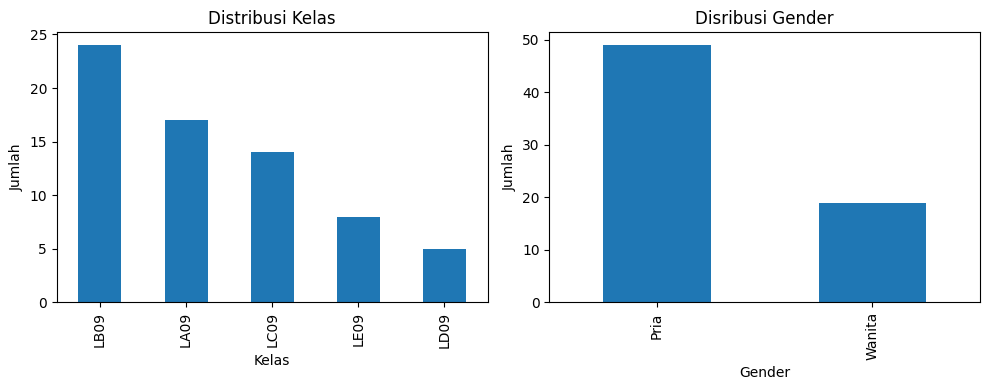

In [397]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df['Kelas'].value_counts().plot(kind = 'bar', ax = ax[0])
ax[0].set_title('Distribusi Kelas')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah')

df['Gender'].value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_xlabel('Gender')
ax[1].set_title('Disribusi Gender')
ax[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

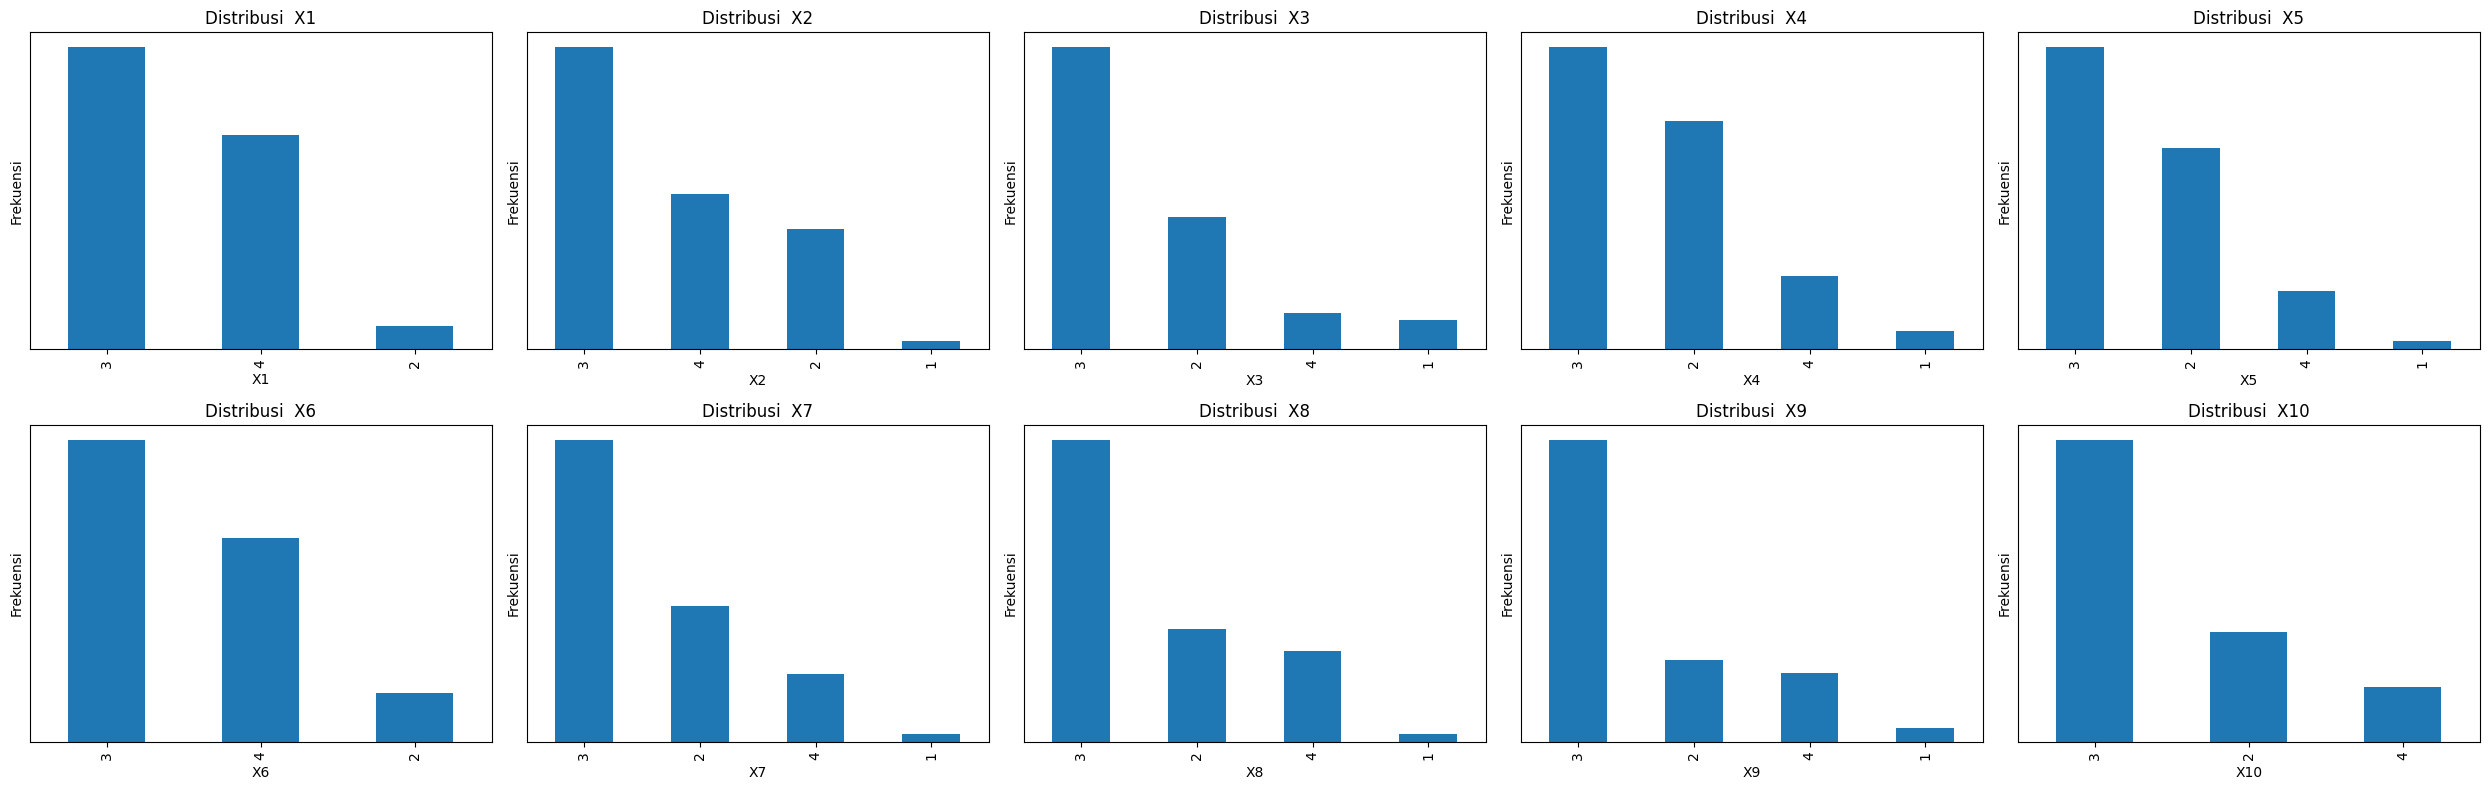

In [398]:
var_x = df.iloc[:, 2:]

fig, ax = plt.subplots(2, 5, figsize=(25, 8))

ax = ax.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

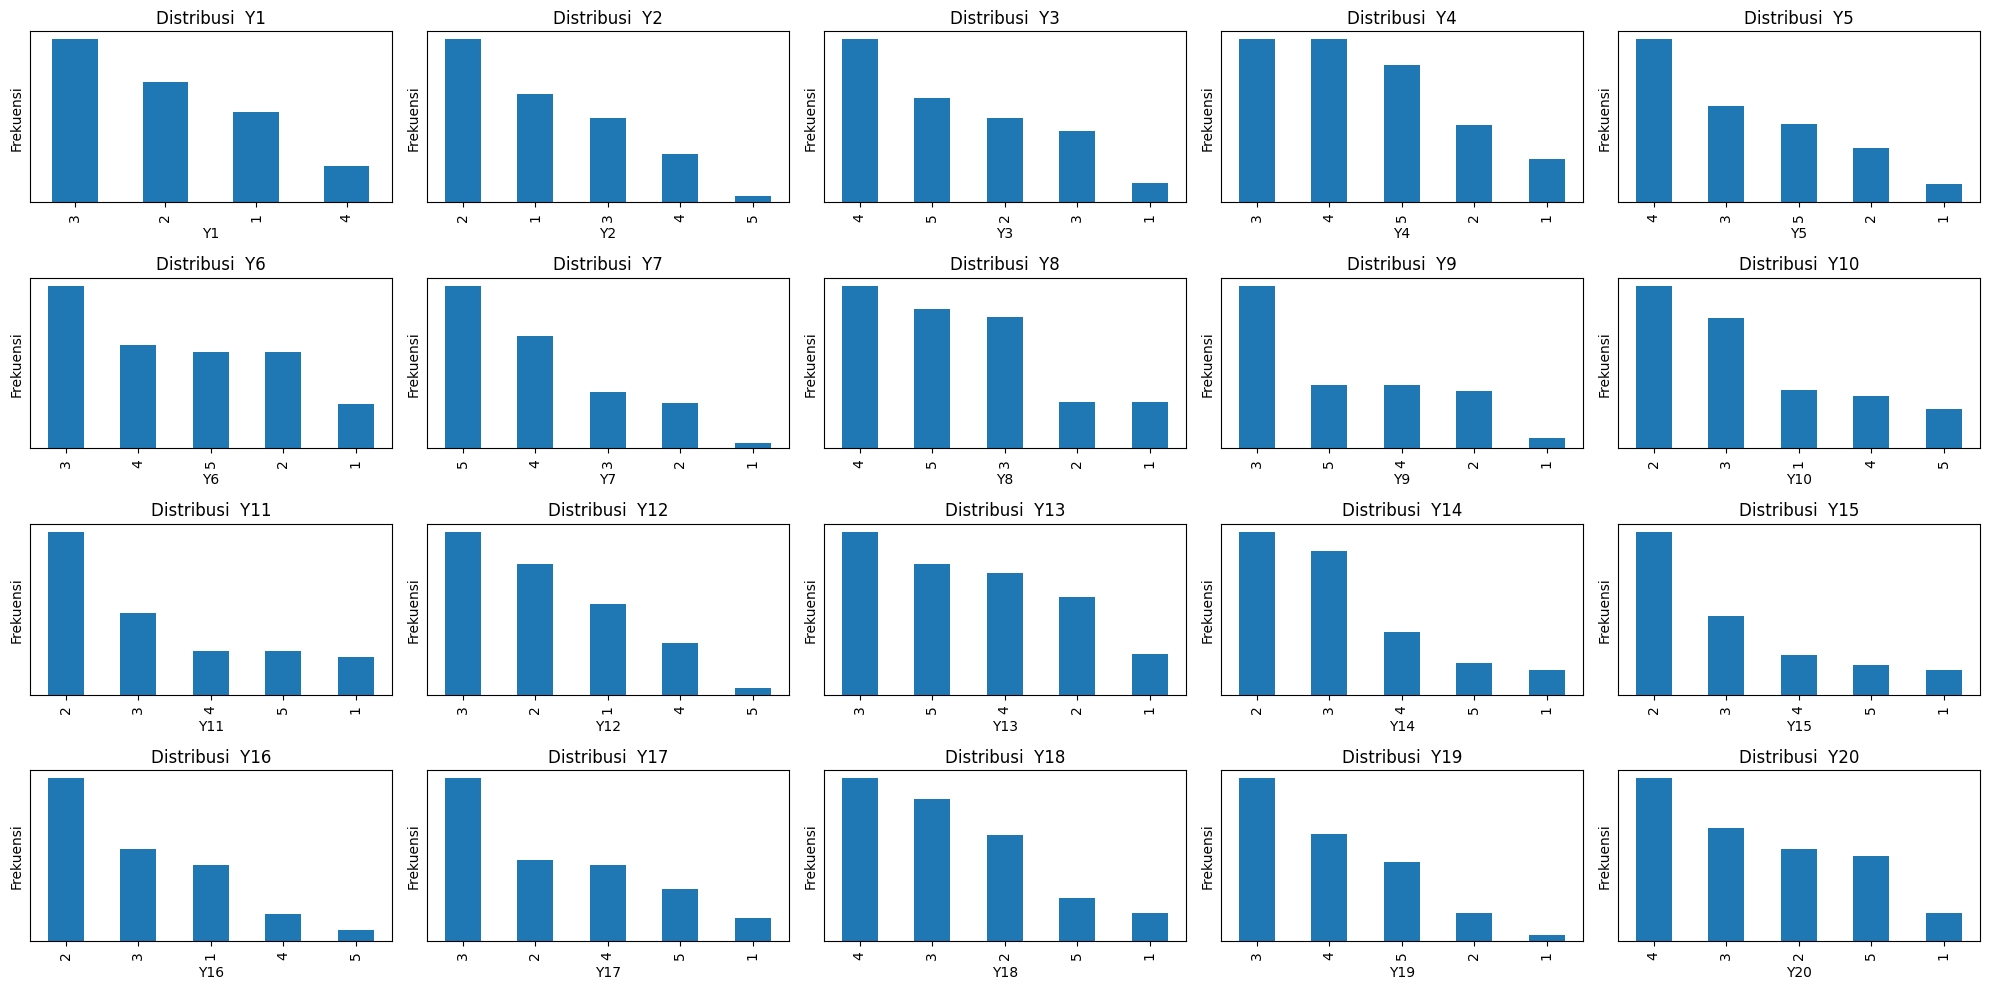

In [399]:
fig, ax = plt.subplots(4, 5, figsize=(20, 10))

ax = ax.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

# Feature Engineering

In [400]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2
3,2,3,4,4,3,3,4,2,2,3,5,4,3,4,4,2,3,3,4,3
4,1,1,2,3,3,3,4,3,3,4,2,2,2,3,3,2,1,4,4,1


In [401]:
df['target'] = var_y.sum(axis = 1) / 20.0

In [402]:
df['target'].head()

0    4.05
1    3.45
2    3.25
3    3.25
4    2.55
Name: target, dtype: float64

In [403]:
faktor_mapping = {
    'Y - Faktor 2': ['Y1', 'Y2', 'Y3', 'Y4', 'Y5'],
    'Y - Faktor 3': ['Y6', 'Y7', 'Y8', 'Y9'],
    'Y - Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'],
    'Y - Faktor 6': ['Y14', 'Y15', 'Y16'],
    'Y - Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20']
}

for nama_faktor, list_indikator in faktor_mapping.items():
    jumlah_soal = float(len(list_indikator))
    df[nama_faktor] = var_y[list_indikator].sum(axis=1) / jumlah_soal

In [404]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,target,Y - Faktor 2,Y - Faktor 3,Y - Faktor 5,Y - Faktor 6,Y - Faktor 7
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2,4.05,4.2,5.00,3.25,3.333333,4.25
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2,3.45,3.0,3.50,3.75,2.000000,4.75
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2,3.25,3.2,3.75,3.75,2.666667,2.75
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4,3.25,3.2,2.75,3.75,3.333333,3.25
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3,2.55,2.0,3.25,2.50,2.666667,2.50


In [405]:
df.columns

Index(['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'target', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5',
       'Y - Faktor 6', 'Y - Faktor 7'],
      dtype='object')

In [406]:
# Model lebih spesifik mencari hubungan detail
# Y_mean = b0 + b1*x1 + ... + b10*x10 + b11*gender + b12*kelas
df_1 = df.copy()
df_1.drop(columns=['Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7'], inplace = True)

# Model tidak spesifik tapi menjelaskan pengaruh X terhadap Y lebih jelas dan sesuai dengan kondisi data (sedikit)
# Y_mean = b0 + b1*X_mean + b2*gender + b3*kelas
# menurut rules of thumb satu prediktor perlu setidaknya 10 - 20 responden (data) dengan total 12 prediktor data saat ini tidak cukup
# bagian ini digunakan untuk menjelaskan pengaruh tiap item secara detail (tetapi tidak dapat dikatakan valid)
df_2 = df_1.copy()
df_2['Efikasi Diri'] = df_2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']].sum(axis = 1) / 4.0
df_2.drop(columns=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], inplace = True)

# Model dilatih dengan membuat target sesuai dengan mean dari faktor Y yang diambil, dikarenakan pada indikator measurement Y hanya mengambil 5 dari 7 faktor
df_3 = df.copy()
df_3['Efikasi Diri'] = df_2['Efikasi Diri']
df_3.drop(columns=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target'], axis = 1, inplace = True)

In [407]:
print(df_1.head(5))

print(df_2.head(5))

print(df_3.head(5))

  Kelas  Gender  X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  target
0  LC09    Pria   3   3   2   2   3   3   2   3   2    2    4.05
1  LA09  Wanita   3   2   2   2   2   3   2   2   2    2    3.45
2  LB09    Pria   4   3   3   2   2   4   3   3   3    2    3.25
3  LB09    Pria   3   3   3   2   3   4   3   4   3    4    3.25
4  LB09  Wanita   3   3   2   2   3   3   3   3   3    3    2.55
  Kelas  Gender  target  Efikasi Diri
0  LC09    Pria    4.05          6.25
1  LA09  Wanita    3.45          5.50
2  LB09    Pria    3.25          7.25
3  LB09    Pria    3.25          8.00
4  LB09  Wanita    2.55          7.00
  Kelas  Gender  Y - Faktor 2  Y - Faktor 3  Y - Faktor 5  Y - Faktor 6  \
0  LC09    Pria           4.2          5.00          3.25      3.333333   
1  LA09  Wanita           3.0          3.50          3.75      2.000000   
2  LB09    Pria           3.2          3.75          3.75      2.666667   
3  LB09    Pria           3.2          2.75          3.75      3.333333   
4  LB09

# Modeling

## df_1 

formula: 

$$Y = \beta_{0} + \beta_{1}X1 + \beta_{2}X2 + ... + \beta_{9}X9 + \beta_{10}X_10 + \beta_{11}kelas + \beta_{12}gender$$

Keterangan:

* **Y** = variabel dependen (tingkat stres rata-rata dengan rentang 1.0 - 5.0).

* **β₀ (intercept)** = nilai dasar (baseline) model yang diperlukan untuk membentuk persamaan regresi.

* **β₁ sampai β₁₀** = koefisien untuk item-item X.

* **β₁₁** = pengaruh variabel kelas terhadap Y.

* **β₁₂** = pengaruh variabel gender terhadap Y.

* **X₁ sampai X₁₀** = 10 item efikasi diri.

* **kelas** dan **gender** = variabel demografi.

In [408]:
x = df_1.drop(columns=['target'])
y = df_1['target']

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15  , random_state=SEED)

# print(x_train.shape)
# print(x_test.shape)

In [409]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

lr_pipeline = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

lr_pipeline.fit(x, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10'], dtype='object'))])),
                ('lr', LinearRegression())])

### Evaluasi Regression

In [410]:
# prediksi
y_pred = lr_pipeline.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.34424081267610734
MSE  : 0.20574640273106914
RMSE : 0.4535927719122838
R2   : 0.3235353938879125


In [411]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr_pipeline,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.40225104410124624


### Interpretasi Model Regression

In [412]:
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

coef = lr_pipeline.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-8.929291
1,ohe__Gender_Wanita,8.929291
2,ohe__Kelas_LA09,-1.299865
3,ohe__Kelas_LB09,4.019425
4,ohe__Kelas_LC09,14.155272
5,ohe__Kelas_LD09,-5.755233
6,ohe__Kelas_LE09,-11.119599
7,other__X1,37.985052
8,other__X2,-0.300561
9,other__X3,-16.896740


## df_2

formula: 

$$Y = \beta_{0} + \beta_{1}X_{mean} + \beta_{2}kelas + \beta_{3}gender$$

Keterangan:

* **Y** = variabel dependen (tingkat stres rata-rata dengan rentang 1.0 - 5.0).

* **β₀ (intercept)**: nilai dasar (baseline) model yang diperlukan untuk membentuk persamaan regresi.

* **β₁**: perubahan rata-rata Y untuk setiap kenaikan 1 poin pada `X_mean`, dengan kelas dan gender tetap.

* **β₂**: perbedaan rata-rata Y antara kategori kelas (misalnya kelas B dibanding kelas A), dengan variabel lain tetap.

* **kelas** dan **gender** = variabel demografi.

In [418]:
x = df_2.drop(columns=['target'])
y = df_2['target']

In [420]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

model2 = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

model2.fit(x, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['Efikasi Diri'], dtype='object'))])),
                ('lr', LinearRegression())])

### Evaluasi Regression

In [421]:
# prediksi
y_pred = model2.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.3895275661146251
MSE  : 0.2543955267573534
RMSE : 0.5043763741070287
R2   : 0.163584065041817


In [423]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model2,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.05427569813488795


### Interpretasi Model Regression

In [424]:
feature_names = model2.named_steps['preprocessor'].get_feature_names_out()

coef = model2.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-9.844425
1,ohe__Gender_Wanita,9.844425
2,ohe__Kelas_LA09,-3.448780
3,ohe__Kelas_LB09,-3.055230
4,ohe__Kelas_LC09,26.635814
5,ohe__Kelas_LD09,-5.832122
6,ohe__Kelas_LE09,-14.299682
7,other__Efikasi Diri,-14.769218


## df_3

formula: 

$$Y_{faktor 2} = \beta_{0} + \beta_{1}X_{mean} + \beta_{2}kelas + \beta_{3}gender$$
$$Y_{faktor 3} = \beta_{0} + \beta_{1}X_{mean} + \beta_{2}kelas + \beta_{3}gender$$
$$Y_{faktor 5} = \beta_{0} + \beta_{1}X_{mean} + \beta_{2}kelas + \beta_{3}gender$$
$$Y_{faktor 6} = \beta_{0} + \beta_{1}X_{mean} + \beta_{2}kelas + \beta_{3}gender$$
$$Y_{faktor 7} = \beta_{0} + \beta_{1}X_{mean} + \beta_{2}kelas + \beta_{3}gender$$

Keterangan:

* **Y** = variabel dependen (tingkat stres rata-rata dengan rentang 1.0 - 5.0).

* **β₀ (intercept)**: nilai dasar (baseline) model yang diperlukan untuk membentuk persamaan regresi.

* **β₁**: perubahan rata-rata Y untuk setiap kenaikan 1 poin pada `X_mean`, dengan kelas dan gender tetap.

* **β₂**: perbedaan rata-rata Y antara kategori kelas (misalnya kelas B dibanding kelas A), dengan variabel lain tetap.

* **kelas** dan **gender** = variabel demografi.

In [426]:
df_3.columns

Index(['Kelas', 'Gender', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5',
       'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri'],
      dtype='object')

In [427]:
x = df_3.drop(columns=['Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7'])
y_2 = df_3['Y - Faktor 2']
y_3 = df_3['Y - Faktor 3']
y_5 = df_3['Y - Faktor 5']
y_6 = df_3['Y - Faktor 6']
y_7 = df_3['Y - Faktor 7']

In [429]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

model3_2 = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

model3_2.fit(x, y_2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['Efikasi Diri'], dtype='object'))])),
                ('lr', LinearRegression())])

In [430]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

model3_3 = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

model3_3.fit(x, y_3)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['Efikasi Diri'], dtype='object'))])),
                ('lr', LinearRegression())])

In [431]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

model3_5 = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

model3_5.fit(x, y_5)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['Efikasi Diri'], dtype='object'))])),
                ('lr', LinearRegression())])

In [432]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

model3_6 = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

model3_6.fit(x, y_6)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['Efikasi Diri'], dtype='object'))])),
                ('lr', LinearRegression())])

In [433]:
lr = LinearRegression()

ohe_col = ['Gender', 'Kelas']
other_col = x.drop(columns = ohe_col).columns

prep = ColumnTransformer([
    ('ohe', OneHotEncoder(), ohe_col),
    ('other', 'passthrough', other_col)
])

model3_7 = Pipeline([
    ('preprocessor', prep),
    ('lr', lr)
])

model3_7.fit(x, y_7)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                                  ['Gender', 'Kelas']),
                                                 ('other', 'passthrough',
                                                  Index(['Efikasi Diri'], dtype='object'))])),
                ('lr', LinearRegression())])

### Evaluasi Regression

In [434]:
# prediksi
y_pred = model3_2.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.3992118897872849
MSE  : 0.27303214507619
RMSE : 0.5225247793896381
R2   : 0.10230954211957777


In [435]:
# prediksi
y_pred = model3_3.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.5708276734988845
MSE  : 0.4729514972818258
RMSE : 0.687714691774013
R2   : -0.5549965592208135


In [436]:
# prediksi
y_pred = model3_5.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.4528054298713113
MSE  : 0.37433588689328945
RMSE : 0.6118299493268448
R2   : -0.23076260347491018


In [437]:
# prediksi
y_pred = model3_6.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.5645825685611602
MSE  : 0.5252973541915433
RMSE : 0.7247740021493205
R2   : -0.72710221456156


In [438]:
# prediksi
y_pred = model3_7.predict(x)

# train metrics
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("=== Eval  ===")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

=== Eval  ===
MAE  : 0.47914618580149515
MSE  : 0.3598013394961577
RMSE : 0.5998344267347097
R2   : -0.1829751002694726


In [ ]:
scores = cross_val_score(
    model3_2,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.05427569813488795


In [440]:
scores = cross_val_score(
    model3_3,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.05427569813488795


In [441]:
scores = cross_val_score(
    model3_5,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.05427569813488795


In [442]:
scores = cross_val_score(
    model3_6,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.05427569813488795


In [443]:
scores = cross_val_score(
    model3_7,
    x,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-0.05427569813488795


### Interpretasi Model Regression

In [445]:
feature_names = model3_2.named_steps['preprocessor'].get_feature_names_out()

coef = model3_2.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-6.681165
1,ohe__Gender_Wanita,6.681165
2,ohe__Kelas_LA09,-12.092481
3,ohe__Kelas_LB09,-16.879361
4,ohe__Kelas_LC09,38.214211
5,ohe__Kelas_LD09,-0.212827
6,ohe__Kelas_LE09,-9.029542
7,other__Efikasi Diri,-22.085639


In [446]:
feature_names = model3_3.named_steps['preprocessor'].get_feature_names_out()

coef = model3_3.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-22.086476
1,ohe__Gender_Wanita,22.086476
2,ohe__Kelas_LA09,-9.168407
3,ohe__Kelas_LB09,-6.319642
4,ohe__Kelas_LC09,27.491770
5,ohe__Kelas_LD09,4.574698
6,ohe__Kelas_LE09,-16.578419
7,other__Efikasi Diri,-11.153344


In [447]:
feature_names = model3_5.named_steps['preprocessor'].get_feature_names_out()

coef = model3_5.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-9.158901
1,ohe__Gender_Wanita,9.158901
2,ohe__Kelas_LA09,-15.771840
3,ohe__Kelas_LB09,15.554664
4,ohe__Kelas_LC09,-4.020062
5,ohe__Kelas_LD09,6.062477
6,ohe__Kelas_LE09,-1.825239
7,other__Efikasi Diri,-8.315222


In [448]:
feature_names = model3_6.named_steps['preprocessor'].get_feature_names_out()

coef = model3_6.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,3.392518
1,ohe__Gender_Wanita,-3.392518
2,ohe__Kelas_LA09,-3.320024
3,ohe__Kelas_LB09,18.557432
4,ohe__Kelas_LC09,17.924229
5,ohe__Kelas_LD09,-20.472832
6,ohe__Kelas_LE09,-12.688804
7,other__Efikasi Diri,-13.087013


In [449]:
feature_names = model3_7.named_steps['preprocessor'].get_feature_names_out()

coef = model3_7.named_steps['lr'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef*100
})

coef_df.head(20)

,Feature,Coefficient
0,ohe__Gender_Pria,-12.169683
1,ohe__Gender_Wanita,12.169683
2,ohe__Kelas_LA09,25.301969
3,ohe__Kelas_LB09,-17.330044
4,ohe__Kelas_LC09,48.496424
5,ohe__Kelas_LD09,-24.177127
6,ohe__Kelas_LE09,-32.291222
7,other__Efikasi Diri,-16.955214
